# SQLite + Pandas — Sales Analysis

**Pipeline:** SQLite (SQL) → Pandas (DataFrame) → Charts (mini reports)

This notebook demonstrates how to connect to a relational database,
run SQL queries directly from Python, and turn the results into visual reports.

**Topics covered:**
- Connecting to SQLite with `sqlite3`
- Running SQL with `pd.read_sql()`
- SELECT, WHERE, ORDER BY, JOIN, GROUP BY
- 4 business reports with charts

## 1. Setup

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

print("Libraries loaded!")

Libraries loaded!


## 2. Connect to SQLite and List Tables

In [2]:
db_path = Path("ybs_shop.sqlite")
if not db_path.exists():
    raise FileNotFoundError("ybs_shop.sqlite not found. Place it in the same folder as this notebook.")

conn = sqlite3.connect(str(db_path))
print("Connected:", db_path)

pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

Connected: ybs_shop.sqlite


,name
0,customers
1,products
2,orders
3,order_items


## 3. First Look at Each Table (SELECT + LIMIT)

In [3]:
pd.read_sql("SELECT * FROM customers LIMIT 5;", conn)

,customer_id,name,city,segment,signup_date
0,1,Customer_001,Istanbul,Premium,2025-09-25
1,2,Customer_002,Ankara,Student,2025-02-26
2,3,Customer_003,Istanbul,Premium,2025-08-08
3,4,Customer_004,Izmir,Student,2025-12-21
4,5,Customer_005,Bursa,Student,2025-03-08


In [4]:
pd.read_sql("SELECT * FROM products LIMIT 5;", conn)

,product_id,product_name,category,unit_price
0,1,Electronics_Item_01,Electronics,1675.81
1,2,Electronics_Item_02,Electronics,828.66
2,3,Electronics_Item_03,Electronics,1839.91
3,4,Electronics_Item_04,Electronics,614.37
4,5,Electronics_Item_05,Electronics,1154.46


In [5]:
pd.read_sql("SELECT * FROM orders LIMIT 5;", conn)

,order_id,customer_id,order_date,channel,payment_method,status
0,1,111,2025-10-22,Web,Card,Delivered
1,2,54,2025-11-14,Web,Transfer,Delivered
2,3,12,2025-08-13,Store,Cash,Delivered
3,4,105,2025-09-07,Web,Card,Delivered
4,5,51,2025-09-11,Web,Card,Delivered


In [6]:
pd.read_sql("SELECT * FROM order_items LIMIT 5;", conn)

,order_item_id,order_id,product_id,quantity,unit_price
0,1,1,24,1,254.44
1,2,1,40,2,208.07
2,3,1,32,3,146.80
3,4,2,9,3,348.17
4,5,2,36,2,163.99


## 4. WHERE + ORDER BY — Most Recent Delivered Orders

In [7]:
query = """
SELECT order_id, customer_id, order_date, channel, payment_method, status
FROM orders
WHERE status = 'Delivered'
ORDER BY order_date DESC
LIMIT 10;
"""
pd.read_sql(query, conn)

,order_id,customer_id,order_date,channel,payment_method,status
0,60,93,2025-12-31,Mobile,Card,Delivered
1,252,40,2025-12-31,Web,Card,Delivered
2,453,95,2025-12-31,Web,Card,Delivered
3,1202,102,2025-12-31,Web,Card,Delivered
4,1520,36,2025-12-31,Mobile,Card,Delivered
5,39,13,2025-12-30,Mobile,Card,Delivered
6,189,95,2025-12-30,Store,Card,Delivered
7,197,95,2025-12-30,Store,Card,Delivered
8,393,24,2025-12-30,Mobile,Cash,Delivered
9,655,84,2025-12-30,Web,Card,Delivered


## 5. JOIN — Full Order Detail

Combine orders, order_items, and products to get line-level detail.

In [8]:
query = """
SELECT
    o.order_id,
    o.order_date,
    o.channel,
    o.status,
    p.category,
    p.product_name,
    oi.quantity,
    oi.unit_price,
    (oi.quantity * oi.unit_price) AS line_total
FROM orders o
JOIN order_items oi ON o.order_id  = oi.order_id
JOIN products   p  ON oi.product_id = p.product_id
LIMIT 10;
"""
pd.read_sql(query, conn)

,order_id,order_date,channel,status,category,product_name,quantity,unit_price,line_total
0,1,2025-10-22,Web,Delivered,Fashion,Fashion_Item_08,1,254.44,254.44
1,1,2025-10-22,Web,Delivered,Beauty,Beauty_Item_08,2,208.07,416.14
2,1,2025-10-22,Web,Delivered,Books,Books_Item_08,3,146.80,440.40
3,2,2025-11-14,Web,Delivered,Home,Home_Item_01,3,348.17,1044.51
4,2,2025-11-14,Web,Delivered,Beauty,Beauty_Item_04,2,163.99,327.98
5,2,2025-11-14,Web,Delivered,Books,Books_Item_05,3,102.90,308.70
6,3,2025-08-13,Store,Delivered,Electronics,Electronics_Item_04,3,607.69,1823.07
7,3,2025-08-13,Store,Delivered,Books,Books_Item_08,3,138.48,415.44
8,3,2025-08-13,Store,Delivered,Beauty,Beauty_Item_01,3,245.03,735.09
9,3,2025-08-13,Store,Delivered,Home,Home_Item_04,1,385.95,385.95


## 6. Report 1 — Monthly Revenue Trend

**Question:** How has revenue grown month by month?  
Only delivered orders count as realized revenue.

In [9]:
query = """
SELECT
    substr(o.order_date, 1, 7)          AS month,
    SUM(oi.quantity * oi.unit_price)    AS revenue,
    COUNT(DISTINCT o.order_id)          AS order_count
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.status = 'Delivered'
GROUP BY month
ORDER BY month;
"""
monthly = pd.read_sql(query, conn)
monthly

,month,revenue,order_count
0,2025-06,516132.58,225
1,2025-07,458312.82,190
2,2025-08,408669.11,202
3,2025-09,453546.63,232
4,2025-10,402850.72,181
5,2025-11,470031.81,213
6,2025-12,462707.08,212


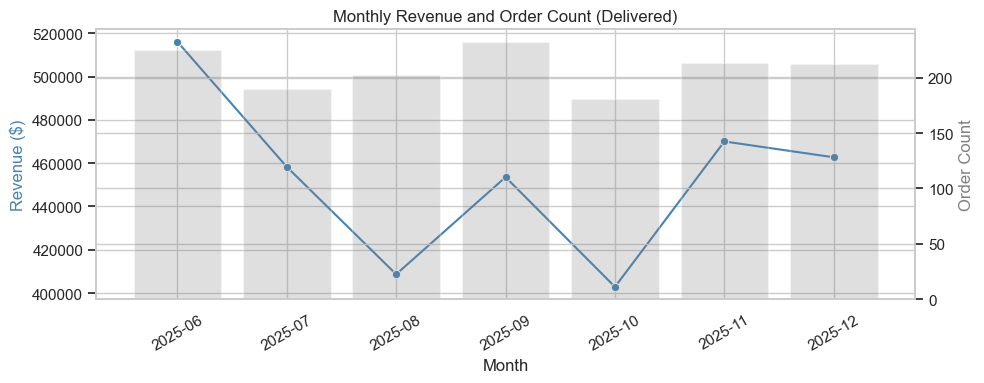

In [10]:
fig, ax1 = plt.subplots(figsize=(10, 4))

sns.lineplot(data=monthly, x="month", y="revenue", marker="o", ax=ax1, color="steelblue")
ax1.set_title("Monthly Revenue and Order Count (Delivered)")
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue ($)", color="steelblue")
ax1.tick_params(axis="x", rotation=30)

ax2 = ax1.twinx()
ax2.bar(monthly["month"], monthly["order_count"], alpha=0.25, color="gray")
ax2.set_ylabel("Order Count", color="gray")

plt.tight_layout()
plt.show()

## 7. Report 2 — Revenue by Sales Channel

In [11]:
query = """
SELECT
    o.channel,
    COUNT(DISTINCT o.order_id)          AS orders,
    SUM(oi.quantity * oi.unit_price)    AS revenue
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.status = 'Delivered'
GROUP BY o.channel
ORDER BY revenue DESC;
"""
channel_rev = pd.read_sql(query, conn)
channel_rev

,channel,orders,revenue
0,Web,663,1433850.31
1,Mobile,584,1261657.64
2,Store,208,476742.80


/var/folders/_p/q81w46n1415_ly8z13fdplyr0000gn/T/ipykernel_11144/1352768648.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_rev, x="channel", y="revenue", palette="Blues_d")


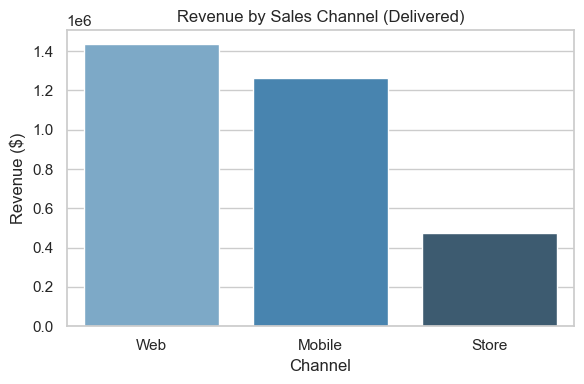

In [12]:
plt.figure(figsize=(6, 4))
sns.barplot(data=channel_rev, x="channel", y="revenue", palette="Blues_d")
plt.title("Revenue by Sales Channel (Delivered)")
plt.xlabel("Channel")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

## 8. Report 3 — Top 5 Categories by Revenue

In [13]:
query = """
SELECT
    p.category,
    COUNT(DISTINCT o.order_id)          AS orders,
    SUM(oi.quantity * oi.unit_price)    AS revenue
FROM orders o
JOIN order_items oi ON o.order_id  = oi.order_id
JOIN products   p  ON oi.product_id = p.product_id
WHERE o.status = 'Delivered'
GROUP BY p.category
ORDER BY revenue DESC
LIMIT 5;
"""
cat_rev = pd.read_sql(query, conn)
cat_rev

,category,orders,revenue
0,Electronics,643,1867161.59
1,Home,595,476809.48
2,Fashion,589,360384.49
3,Beauty,629,281609.79
4,Books,584,186285.40


/var/folders/_p/q81w46n1415_ly8z13fdplyr0000gn/T/ipykernel_11144/2495160335.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_rev, x="category", y="revenue", palette="Greens_d")


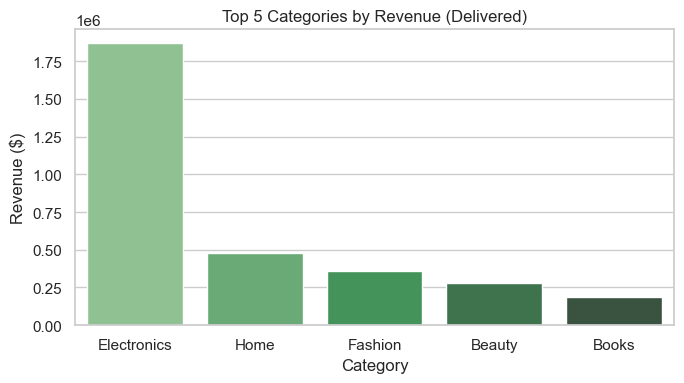

In [14]:
plt.figure(figsize=(7, 4))
sns.barplot(data=cat_rev, x="category", y="revenue", palette="Greens_d")
plt.title("Top 5 Categories by Revenue (Delivered)")
plt.xlabel("Category")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

## 9. Report 4 — City Performance

Revenue and unique customer count per city — useful for regional strategy.

In [15]:
query = """
SELECT
    c.city,
    COUNT(DISTINCT c.customer_id)       AS unique_customers,
    COUNT(DISTINCT o.order_id)          AS orders,
    SUM(oi.quantity * oi.unit_price)    AS revenue,
    ROUND(
        SUM(oi.quantity * oi.unit_price) * 1.0
        / COUNT(DISTINCT o.order_id), 2
    )                                   AS avg_order_value
FROM customers   c
JOIN orders      o  ON c.customer_id  = o.customer_id
JOIN order_items oi ON o.order_id     = oi.order_id
WHERE o.status = 'Delivered'
GROUP BY c.city
ORDER BY revenue DESC;
"""
city_report = pd.read_sql(query, conn)
city_report

,city,unique_customers,orders,revenue,avg_order_value
0,Istanbul,59,681,1456665.07,2139.01
1,Ankara,26,330,726632.39,2201.92
2,Bursa,15,184,421832.16,2292.57
3,Izmir,12,148,315312.77,2130.49
4,Antalya,8,112,251808.36,2248.29


/var/folders/_p/q81w46n1415_ly8z13fdplyr0000gn/T/ipykernel_11144/4200082600.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_report, x="city", y="revenue", palette="Oranges_d")


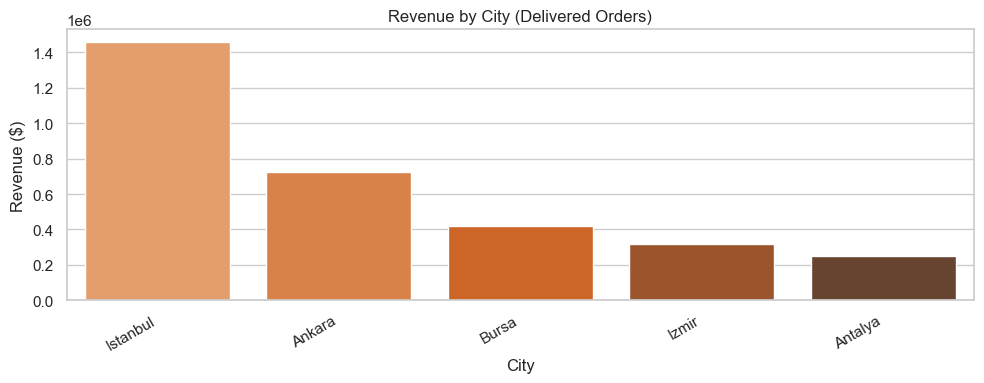

In [16]:
plt.figure(figsize=(10, 4))
sns.barplot(data=city_report, x="city", y="revenue", palette="Oranges_d")
plt.title("Revenue by City (Delivered Orders)")
plt.xlabel("City")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 10. Close Connection

In [17]:
conn.close()
print("Connection closed.")

Connection closed.
